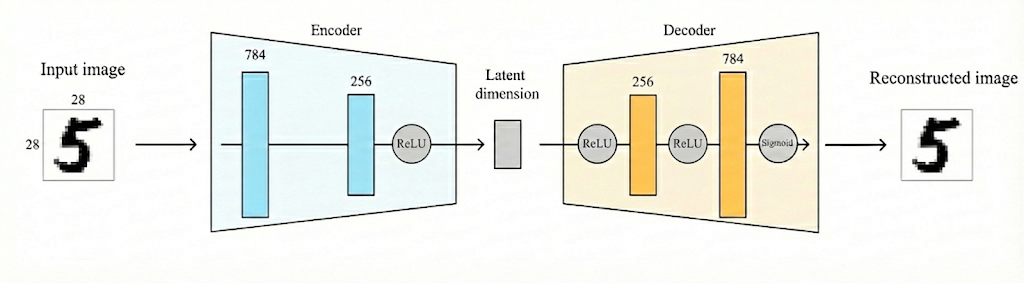

In [2]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# device selection
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# data into train and val

BATCH_SIZE = 128

data_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform = data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)



100%|██████████| 9.91M/9.91M [00:00<00:00, 20.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 497kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.61MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.7MB/s]


In [15]:
class Autoencoder(nn.Module):
  def __init__(self, latent_dim = 32, hidden_dim = 256):
    super().__init__()

    # Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU(),
    )

    # Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid(),
    )

  # forward method
  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

In [16]:
# defining the model loss

model = Autoencoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [21]:
epochs = 15

model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()
    x_recon = model(x)

    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss +  loss.item()

  avg_loss = total_loss / len(train_loader)

  print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [1/15], Loss: 0.012818
Epoch [2/15], Loss: 0.012408
Epoch [3/15], Loss: 0.012061
Epoch [4/15], Loss: 0.011783
Epoch [5/15], Loss: 0.011538
Epoch [6/15], Loss: 0.011312
Epoch [7/15], Loss: 0.011113
Epoch [8/15], Loss: 0.010935
Epoch [9/15], Loss: 0.010787
Epoch [10/15], Loss: 0.010633
Epoch [11/15], Loss: 0.010505
Epoch [12/15], Loss: 0.010394
Epoch [13/15], Loss: 0.010275
Epoch [14/15], Loss: 0.010181
Epoch [15/15], Loss: 0.010073


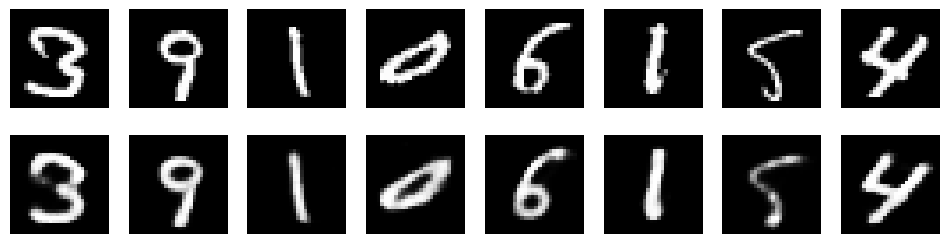

In [22]:
model.eval()

with torch.no_grad():
  x , _ = next(iter(train_loader))
  x = x.view(-1, 784).to(device)

  x_recon = model(x)

  # x = x.cpu()

  n = 8
  plt.figure(figsize=(12, 3))
  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28, 28), cmap='gray')
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28, 28), cmap='gray')
    plt.axis("off")

  plt.show()

In [23]:
model.eval()

latents = []
labels = []

with torch.no_grad():
  for x, y in train_loader:
    x = x.view(-1, 784).to(device)
    z = model.encoder(x)

    latents.append(z.cpu())
    labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

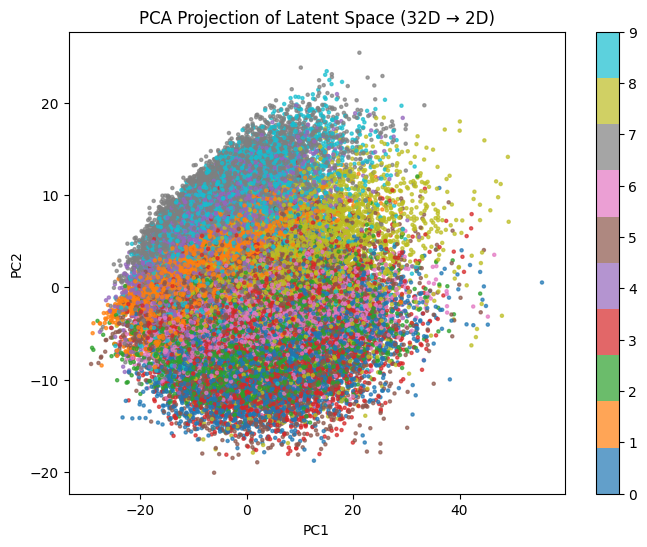

In [24]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

latent_dim = latents.shape[1]

# Ensure numpy
z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

if latent_dim == 1:
    # --------- 1D: Histogram + Strip plot ------------
    plt.figure(figsize=(8, 4))
    for digit in range(10):
        plt.hist(
            z[y == digit].flatten(),
            bins=50,
            alpha=0.5,
            label=str(digit),
        )

    plt.xlabel("Latent Value")
    plt.ylabel("Frequency")
    plt.title("1D Latent Distribution by Class")
    plt.legend()
    plt.show()

elif latent_dim == 2:
    # ---------- 2D Scatter plot -----------------------
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        z[:, 0], z[:, 1],
        c=y,
        cmap='tab10',
        s=5,
        alpha=0.7
    )

    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("2D Latent Space")
    plt.show()

elif latent_dim == 3:
    # ---------- 3D Rotatable Scatter plot -----------------------
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        z[:, 0], z[:, 1], z[:, 2],
        c=y,
        cmap='tab10',
        s=5,
        alpha=0.7
    )

    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.set_title("3D Latent Space")
    fig.colorbar(scatter, ticks=range(10))
    plt.show()

else:
    # ------------ >3D: PCA Projection ---------------------
    pca_dim = 2
    pca = PCA(n_components=pca_dim)
    z_pca = pca.fit_transform(z)

    if pca_dim == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            z_pca[:, 0], z_pca[:, 1],
            c=y,
            cmap='tab10',
            s=5,
            alpha=0.7
        )

        plt.colorbar(scatter, ticks=range(10))
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"PCA Projection of Latent Space ({latent_dim}D → 2D)")
        plt.show()

    else:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(
            z_pca[:, 0], z_pca[:, 1], z_pca[:, 2],
            c=y,
            cmap='tab10',
            s=5,
            alpha=0.7
        )

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.set_title(f"PCA Projection of Latent Space ({latent_dim}D → 3D)")
        fig.colorbar(scatter, ticks=range(10))
        plt.show()

#### Lets pick a random sample from distribution and see reconstruction

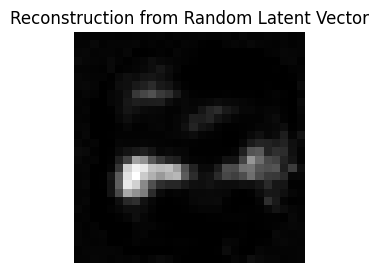

In [25]:
model.eval()

with torch.no_grad():
  latent_dim = model.encoder[-2].out_features  # or just use the value you passed
  z_random = torch.randn(1, latent_dim)
  z_random.to(device)

  x_generated = model.decoder(z_random)
  x_generated = x_generated.cpu().view(28,28)

plt.figure(figsize=(3, 3))
plt.imshow(x_generated, cmap='gray')
plt.axis("off")
plt.title("Reconstruction from Random Latent Vector")
plt.show()

## You can see this is such a messy reconstruction

# So to overcome this failure we get to new form ---> Variational Autoencoders (VAE)

# FashionMNIST

In [26]:
# data into train and val

BATCH_SIZE = 128

data_transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform = data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)



100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 209kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.5MB/s]


In [27]:
class Autoencoder(nn.Module):
  def __init__(self, latent_dim = 32, hidden_dim = 256):
    super().__init__()

    # Encoder
    self.encoder = nn.Sequential(
        nn.Linear(784, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, latent_dim),
        nn.ReLU(),
    )

    # Decoder
    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, 784),
        nn.Sigmoid(),
    )

  # forward method
  def forward(self, x):
    z = self.encoder(x)
    x_recon = self.decoder(z)
    return x_recon

In [28]:
# defining the model loss

model = Autoencoder()

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [29]:
epochs = 20

model.train()
for epoch in range(epochs):
  total_loss = 0
  for x, _ in train_loader:
    x = x.view(-1, 784).to(device)

    optimizer.zero_grad()
    x_recon = model(x)

    loss = criterion(x_recon, x)
    loss.backward()
    optimizer.step()

    total_loss = total_loss +  loss.item()

  avg_loss = total_loss / len(train_loader)

  print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [1/20], Loss: 0.034183
Epoch [2/20], Loss: 0.018181
Epoch [3/20], Loss: 0.015713
Epoch [4/20], Loss: 0.014358
Epoch [5/20], Loss: 0.013479
Epoch [6/20], Loss: 0.012873
Epoch [7/20], Loss: 0.012437
Epoch [8/20], Loss: 0.012076
Epoch [9/20], Loss: 0.011804
Epoch [10/20], Loss: 0.011605
Epoch [11/20], Loss: 0.011413
Epoch [12/20], Loss: 0.011260
Epoch [13/20], Loss: 0.011122
Epoch [14/20], Loss: 0.010996
Epoch [15/20], Loss: 0.010868
Epoch [16/20], Loss: 0.010721
Epoch [17/20], Loss: 0.010596
Epoch [18/20], Loss: 0.010520
Epoch [19/20], Loss: 0.010425
Epoch [20/20], Loss: 0.010340


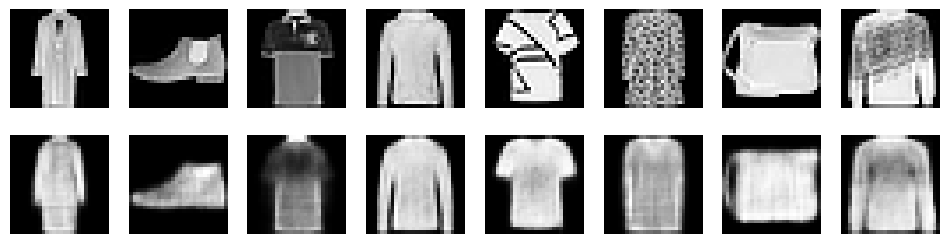

In [34]:
model.eval()

with torch.no_grad():
  x , _ = next(iter(train_loader))
  x = x.view(-1, 784).to(device)

  x_recon = model(x)

  # x = x.cpu()

  n = 8
  plt.figure(figsize=(12, 3))
  for i in range(n):
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28, 28), cmap='gray')
    plt.axis("off")

    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[i].view(28, 28), cmap='gray')
    plt.axis("off")

  plt.show()

In [31]:
model.eval()

latents = []
labels = []

with torch.no_grad():
  for x, y in train_loader:
    x = x.view(-1, 784).to(device)
    z = model.encoder(x)

    latents.append(z.cpu())
    labels.append(y)

latents = torch.cat(latents, dim=0)
labels = torch.cat(labels, dim=0)

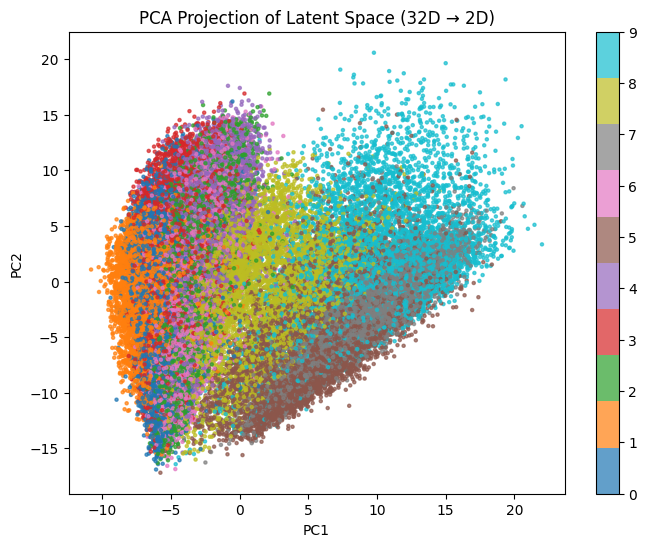

In [32]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

latent_dim = latents.shape[1]

# Ensure numpy
z = latents.detach().cpu().numpy()
y = labels.detach().cpu().numpy()

if latent_dim == 1:
    # --------- 1D: Histogram + Strip plot ------------
    plt.figure(figsize=(8, 4))
    for digit in range(10):
        plt.hist(
            z[y == digit].flatten(),
            bins=50,
            alpha=0.5,
            label=str(digit),
        )

    plt.xlabel("Latent Value")
    plt.ylabel("Frequency")
    plt.title("1D Latent Distribution by Class")
    plt.legend()
    plt.show()

elif latent_dim == 2:
    # ---------- 2D Scatter plot -----------------------
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(
        z[:, 0], z[:, 1],
        c=y,
        cmap='tab10',
        s=5,
        alpha=0.7
    )

    plt.colorbar(scatter, ticks=range(10))
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("2D Latent Space")
    plt.show()

elif latent_dim == 3:
    # ---------- 3D Rotatable Scatter plot -----------------------
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(
        z[:, 0], z[:, 1], z[:, 2],
        c=y,
        cmap='tab10',
        s=5,
        alpha=0.7
    )

    ax.set_xlabel("z1")
    ax.set_ylabel("z2")
    ax.set_zlabel("z3")
    ax.set_title("3D Latent Space")
    fig.colorbar(scatter, ticks=range(10))
    plt.show()

else:
    # ------------ >3D: PCA Projection ---------------------
    pca_dim = 2
    pca = PCA(n_components=pca_dim)
    z_pca = pca.fit_transform(z)

    if pca_dim == 2:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(
            z_pca[:, 0], z_pca[:, 1],
            c=y,
            cmap='tab10',
            s=5,
            alpha=0.7
        )

        plt.colorbar(scatter, ticks=range(10))
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.title(f"PCA Projection of Latent Space ({latent_dim}D → 2D)")
        plt.show()

    else:
        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        scatter = ax.scatter(
            z_pca[:, 0], z_pca[:, 1], z_pca[:, 2],
            c=y,
            cmap='tab10',
            s=5,
            alpha=0.7
        )

        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.set_zlabel("PC3")
        ax.set_title(f"PCA Projection of Latent Space ({latent_dim}D → 3D)")
        fig.colorbar(scatter, ticks=range(10))
        plt.show()

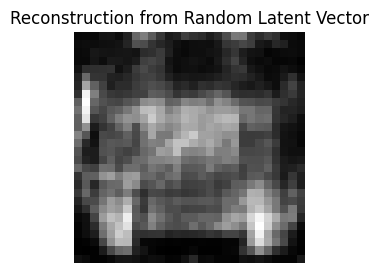

In [33]:
model.eval()

with torch.no_grad():
  latent_dim = model.encoder[-2].out_features  # or just use the value you passed
  z_random = torch.randn(1, latent_dim)
  z_random.to(device)

  x_generated = model.decoder(z_random)
  x_generated = x_generated.cpu().view(28,28)

plt.figure(figsize=(3, 3))
plt.imshow(x_generated, cmap='gray')
plt.axis("off")
plt.title("Reconstruction from Random Latent Vector")
plt.show()